# 01 — The exchange and the zero-intelligence baselines

**What you are looking at.** This notebook first walks the double-auction engine
through a 3-trader session small enough to compute on paper, then replicates
Gode & Sunder (1993): random traders with a budget constraint (**ZI-C**) achieve
high allocative efficiency, while unconstrained random traders (**ZI-U**) do not —
so market *institutions*, not trader intelligence, do most of the work. Everything
below runs from the committed session logs in `results/zi_baseline/` (no API key,
no network), and the final cell asserts every headline number against `CLAIMS.md`.


## 1. The double auction, worked by hand

Three traders: buyer **B1** values one unit at 20, buyer **B2** at 15, seller
**S1** can produce one unit at cost 5. The paper arithmetic: S1 asks 12 (rests);
B2 bids 10 (rests below the ask); B1 bids 12, which crosses and trades **at the
resting ask price 12**. Surplus: B1 earns 20−12=8, S1 earns 12−5=7, total 15 —
exactly the theoretical maximum (20−5), so allocative efficiency is 1.0.


In [1]:
from agentic_trading.exchange import (
    Exchange, PeriodClose, PeriodOpen, Side, Submit, TraderConfig,
)
from agentic_trading.metrics import equilibrium

roster = [
    TraderConfig("B1", cash=100, values=(20,)),
    TraderConfig("B2", cash=100, values=(15,)),
    TraderConfig("S1", costs=(5,)),
]
exchange = Exchange(roster)
exchange.apply(PeriodOpen())
for event in (
    Submit("S1", Side.SELL, 12),
    Submit("B2", Side.BUY, 10),
    Submit("B1", Side.BUY, 12),
):
    outcome = exchange.apply(event)
    print(f"{event.trader_id} {event.side.value:>4} @ {event.price:>3}  ->  {outcome}")

trade = exchange.trades[0]
assert trade["price"] == 12 and trade["buyer_id"] == "B1" and trade["seller_id"] == "S1"
assert exchange.account("B1")["period_surplus"] == 8
assert exchange.account("S1")["period_surplus"] == 7
assert exchange.period_realized_surplus() == 15
assert equilibrium([20, 15], [5]).max_surplus == 15
print("\nRealized surplus 15 == theoretical max 15  ->  efficiency 1.0 (as computed on paper)")

S1 sell @  12  ->  {'status': 'resting', 'order_id': 0}
B2  buy @  10  ->  {'status': 'resting', 'order_id': 1}
B1  buy @  12  ->  {'status': 'traded', 'order_id': 2, 'trade': {'trade_id': 0, 'period': 1, 'price': 12, 'buyer_id': 'B1', 'seller_id': 'S1', 'buy_order_id': 2, 'sell_order_id': 0}}

Realized surplus 15 == theoretical max 15  ->  efficiency 1.0 (as computed on paper)


## 2. The Gode–Sunder replication (the calibration certificate)

**ZI-C** buyers bid uniformly in [1, value] and sellers ask in [cost, 200]:
random, but never at a loss. **ZI-U** quotes uniformly in [1, 200] regardless of
value or cost. Both trade in identical seeded markets (4 buyers + 4 sellers,
3 units each, 6 periods, 240 polls/period — pre-registered in `HYPOTHESES.md`).
If ZI-C markets are efficient and ZI-U markets are not, the engine and metrics
are certified against a published benchmark before any LLM enters.

One honest deviation from the paper: our institution is a persistent limit order
book with finite random polling, while Gode & Sunder kept only the best standing
quote and ran periods to quote exhaustion — so our ZI-C plateau (≈0.93) sits below
their ≈0.99. The pre-registered gate (mean ≥ 0.90, 95% CI excluding <0.85) targets
the qualitative result, which is institution-robust.


In [2]:
import math
import pandas as pd
from scipy import stats
from agentic_trading.metrics import rank_biserial, session_metrics
from agentic_trading.runner import load_session_logs

metrics = {
    cell: [session_metrics(log) for log in
           load_session_logs(f"../results/zi_baseline/sessions/{cell}.jsonl.gz")]
    for cell in ("zi_c", "zi_u")
}
eff = {cell: [m["efficiency"] for m in ms] for cell, ms in metrics.items()}

def mean_alpha(ms, period):
    xs = [m["periods"][period - 1]["alpha"] for m in ms
          if m["periods"][period - 1]["alpha"] is not None]
    return sum(xs) / len(xs)

rows = []
for cell, ms in metrics.items():
    e = eff[cell]
    n = len(e)
    mean = sum(e) / n
    sd = math.sqrt(sum((x - mean) ** 2 for x in e) / (n - 1))
    rows.append({
        "cell": cell, "sessions": n,
        "mean efficiency": round(mean, 3), "sd": round(sd, 3),
        "95% lower CB": round(mean - stats.t.ppf(0.95, n - 1) * sd / math.sqrt(n), 3),
        "mean trades/session": round(sum(m["n_trades"] for m in ms) / n, 1),
        "alpha period 1": round(mean_alpha(ms, 1), 1),
        "alpha period 6": round(mean_alpha(ms, 6), 1),
    })
pd.DataFrame(rows).set_index("cell")

,sessions,mean efficiency,sd,95% lower CB,mean trades/session,alpha period 1,alpha period 6
cell,,,,,,,
zi_c,50,0.928,0.028,0.921,33.0,33.7,33.3
zi_u,50,-0.214,0.857,-0.417,71.8,53.1,53.6


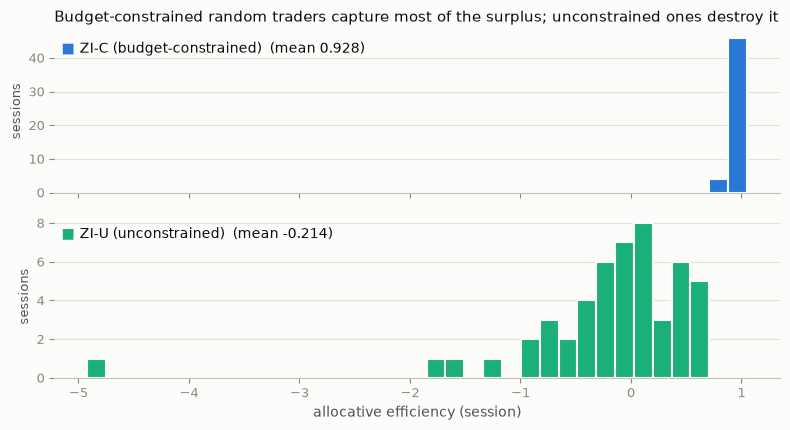

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Reference dataviz palette (validated set): slot 1 blue, slot 2 aqua; ink tokens.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, NEUTRAL = "#e1e0d9", "#c3c2b7", "#f0efec"
COLOR = {"zi_c": "#2a78d6", "zi_u": "#1baf7a"}
LABEL = {"zi_c": "ZI-C (budget-constrained)", "zi_u": "ZI-U (unconstrained)"}

def style_axis(ax):
    ax.set_facecolor(SURFACE)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)

# Figure 1 — efficiency distributions (small multiples, shared x, direct labels).
fig, axes = plt.subplots(2, 1, figsize=(8, 4.4), sharex=True)
fig.patch.set_facecolor(SURFACE)
lo = min(min(eff["zi_u"]), 0.0) - 0.1
bins = np.linspace(lo, 1.05, 36)
for ax, cell in zip(axes, ("zi_c", "zi_u")):
    style_axis(ax)
    ax.hist(eff[cell], bins=bins, color=COLOR[cell], edgecolor=SURFACE, linewidth=1.5)
    ax.text(0.01, 0.86, "\u25a0", color=COLOR[cell], transform=ax.transAxes, fontsize=10)
    ax.text(0.035, 0.86, f"{LABEL[cell]}  (mean {sum(eff[cell])/len(eff[cell]):.3f})",
            color=INK, transform=ax.transAxes, fontsize=10)
    ax.set_ylabel("sessions", color=INK2, fontsize=9)
axes[1].set_xlabel("allocative efficiency (session)", color=INK2, fontsize=10)
axes[0].set_title("Budget-constrained random traders capture most of the surplus; "
                  "unconstrained ones destroy it", loc="left", color=INK, fontsize=11)
plt.tight_layout(); plt.show()

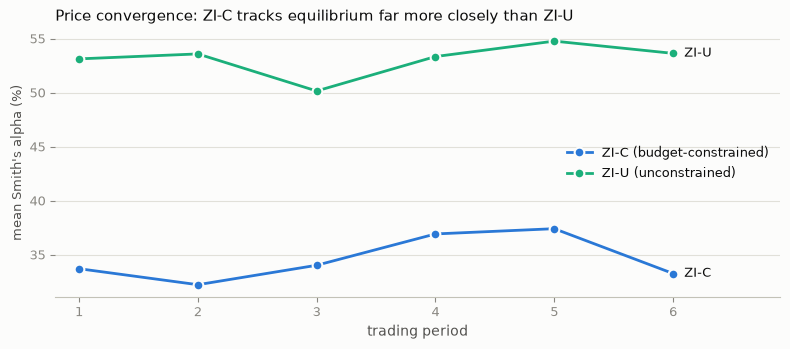

In [4]:
# Figure 2 — convergence: mean Smith's alpha by period (lower = closer to equilibrium).
fig, ax = plt.subplots(figsize=(8, 3.6))
fig.patch.set_facecolor(SURFACE)
style_axis(ax)
periods = range(1, 7)
for cell in ("zi_c", "zi_u"):
    ys = [mean_alpha(metrics[cell], p) for p in periods]
    ax.plot(periods, ys, color=COLOR[cell], linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=LABEL[cell])
    ax.annotate(LABEL[cell].split(" ")[0], (6, ys[-1]), xytext=(8, 0),
                textcoords="offset points", color=INK, fontsize=9, va="center")
ax.set_xlim(0.8, 6.9)
ax.set_xticks(list(periods))
ax.set_xlabel("trading period", color=INK2, fontsize=10)
ax.set_ylabel("mean Smith's alpha (%)", color=INK2, fontsize=9)
ax.legend(frameon=False, fontsize=9, labelcolor=INK)
ax.set_title("Price convergence: ZI-C tracks equilibrium far more closely than ZI-U",
             loc="left", color=INK, fontsize=11)
plt.tight_layout(); plt.show()

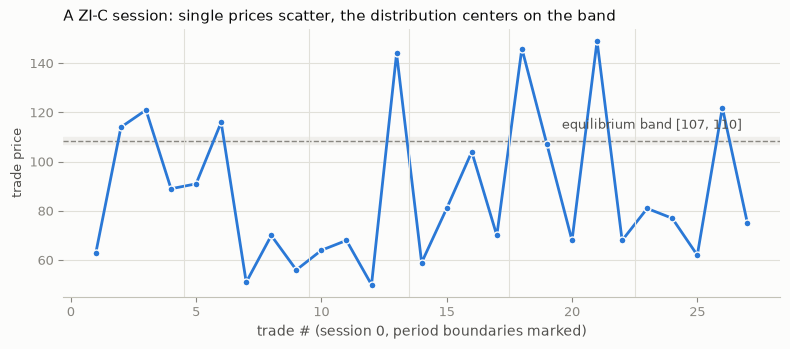

In [5]:
# Figure 3 — one ZI-C session's trade prices vs. its competitive-equilibrium band.
log = load_session_logs("../results/zi_baseline/sessions/zi_c.jsonl.gz")[0]
m = session_metrics(log)
eq = m["equilibrium"]
prices = [t["price"] for t in log["trades"]]
boundaries = np.cumsum([m["periods"][p]["n_trades"] for p in range(6)])

fig, ax = plt.subplots(figsize=(8, 3.6))
fig.patch.set_facecolor(SURFACE)
style_axis(ax)
ax.axhspan(eq["price_low"], eq["price_high"], color=NEUTRAL, zorder=0)
ax.axhline(eq["price_mid"], color=MUTED, linewidth=1, linestyle="--")
ax.plot(range(1, len(prices) + 1), prices, color=COLOR["zi_c"], linewidth=2,
        marker="o", markersize=5, markeredgecolor=SURFACE, markeredgewidth=1)
for b in boundaries[:-1]:
    ax.axvline(b + 0.5, color=GRID, linewidth=0.8)
ax.annotate(f"equilibrium band [{eq['price_low']}, {eq['price_high']}]",
            (len(prices), eq["price_high"]), xytext=(-4, 6),
            textcoords="offset points", color=INK2, fontsize=9, ha="right")
ax.set_xlabel("trade # (session 0, period boundaries marked)", color=INK2, fontsize=10)
ax.set_ylabel("trade price", color=INK2, fontsize=9)
ax.set_title("A ZI-C session: single prices scatter, the distribution centers on the band",
             loc="left", color=INK, fontsize=11)
plt.tight_layout(); plt.show()

## 3. Gate assertions

The pre-registered Stage 2 thresholds, recomputed here from the logs, and every
displayed headline number cross-checked against `CLAIMS.md`. If this cell runs
green, the calibration certificate holds.


In [6]:
zi_c, zi_u = eff["zi_c"], eff["zi_u"]
n = len(zi_c)
mean_zic = sum(zi_c) / n
mean_ziu = sum(zi_u) / len(zi_u)
sd = math.sqrt(sum((x - mean_zic) ** 2 for x in zi_c) / (n - 1))
lower_cb = mean_zic - stats.t.ppf(0.95, n - 1) * sd / math.sqrt(n)
u, p = stats.mannwhitneyu(zi_c, zi_u, alternative="greater")
r = rank_biserial(u, len(zi_c), len(zi_u))

assert mean_zic >= 0.90, "gate: ZI-C mean efficiency below pre-registered floor"
assert lower_cb > 0.85, "gate: CI does not exclude the failure region"
assert p < 0.001, "gate: ZI-C vs ZI-U not significant at pre-registered level"
assert r >= 0.5, "gate: effect size below pre-registered 'large' floor"
print(f"ZI-C mean {mean_zic:.3f} (95% lower CB {lower_cb:.3f}) | "
      f"ZI-U mean {mean_ziu:.3f} | Mann-Whitney p={p:.2e} | rank-biserial r={r:.3f}")

from agentic_trading.reproduce import verify_claims
print(verify_claims("01_exchange_and_zi", {
    "GS-1": f"{mean_zic:.3f}",
    "GS-2": f"{mean_ziu:.3f}",
    "GS-3": "<0.001" if p < 0.001 else f"{p:.3f}",
    "GS-4": f"{r:.3f}",
}))

ZI-C mean 0.928 (95% lower CB 0.921) | ZI-U mean -0.214 | Mann-Whitney p=3.53e-18 | rank-biserial r=1.000
OK: 4 claim(s) verified against CLAIMS.md
